In [9]:
# LIBRERÍAS
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# CONFIGURACIÓN
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("COINMARKETCAP_API_KEY")

if not API_KEY:
    raise ValueError("No se encontró COINMARKETCAP_API_KEY en las variables de entorno.")
url = "https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest"

headers = {
    "X-CMC_PRO_API_KEY": API_KEY
}
params = {
    "start": "1",
    "limit": "2000",
    "convert": "USD"
}

In [11]:
# DESCARGA DE DATOS
response = requests.get(url, headers=headers, params=params)
data = response.json()

df = pd.json_normalize(data["data"])

In [12]:
# CLASIFICACIÓN DE PROYECTOS
categories = {
    "Inteligencia Artificial": ["ai", "artificial-intelligence", "machine-learning"],
    "Videojuegos": ["gaming", "game", "play-to-earn", "metaverse"],
    "RWA": ["rwa", "real-world-assets", "tokenization"],
    "Memes": ["memes", "meme", "doge", "shiba"]
}

def classify_project(tags):
    if not isinstance(tags, list):
        return None
    tags_lower = [t.lower() for t in tags]
    for cat, keywords in categories.items():
        if any(k in t for k in keywords for t in tags_lower):
            return cat
    return None

df["category_custom"] = df["tags"].apply(classify_project)
df_filtered = df[df["category_custom"].notnull()].copy()

print("Cantidad de proyectos clasificados:", len(df_filtered))

Cantidad de proyectos clasificados: 1276


In [13]:
# CREACIÓN DEL GRAFO
G = nx.Graph()

for _, row in df_filtered.iterrows():
    G.add_node(
        row["symbol"],
        name=row["name"],
        category=row["category_custom"],
        market_cap=row["quote.USD.market_cap"],
        volume_24h=row["quote.USD.volume_24h"],
        tags=row["tags"]
    )

def calcular_peso(attr1, attr2):
    peso = 0
    # 1. Misma categoría -> +2
    if attr1["category"] == attr2["category"]:
        peso += 2
    # 2. Similitud en Market Cap (si la diferencia < 10%)
    mc1, mc2 = attr1["market_cap"], attr2["market_cap"]
    if mc1 and mc2 and mc1 > 0 and mc2 > 0:
        ratio = abs(mc1 - mc2) / max(mc1, mc2)
        if ratio < 0.1:
            peso += 1
    # 3. Similitud en Volumen (si la diferencia < 15%)
    v1, v2 = attr1["volume_24h"], attr2["volume_24h"]
    if v1 and v2 and v1 > 0 and v2 > 0:
        ratio = abs(v1 - v2) / max(v1, v2)
        if ratio < 0.15:
            peso += 1
    # 4. Coincidencia en al menos 1 tag
    tags1 = set(attr1["tags"]) if attr1["tags"] else set()
    tags2 = set(attr2["tags"]) if attr2["tags"] else set()
    if tags1.intersection(tags2):
        peso += 1

    return peso

In [14]:
# AÑADIR ARISTAS CON PESOS
symbols = list(df_filtered["symbol"])
for i in range(len(symbols)):
    for j in range(i+1, len(symbols)):
        attr1 = G.nodes[symbols[i]]
        attr2 = G.nodes[symbols[j]]
        peso = calcular_peso(attr1, attr2)
        if peso > 0:  # solo conectamos si hay relación
            G.add_edge(symbols[i], symbols[j], weight=peso)

print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())

Número de nodos: 1242
Número de aristas: 598916


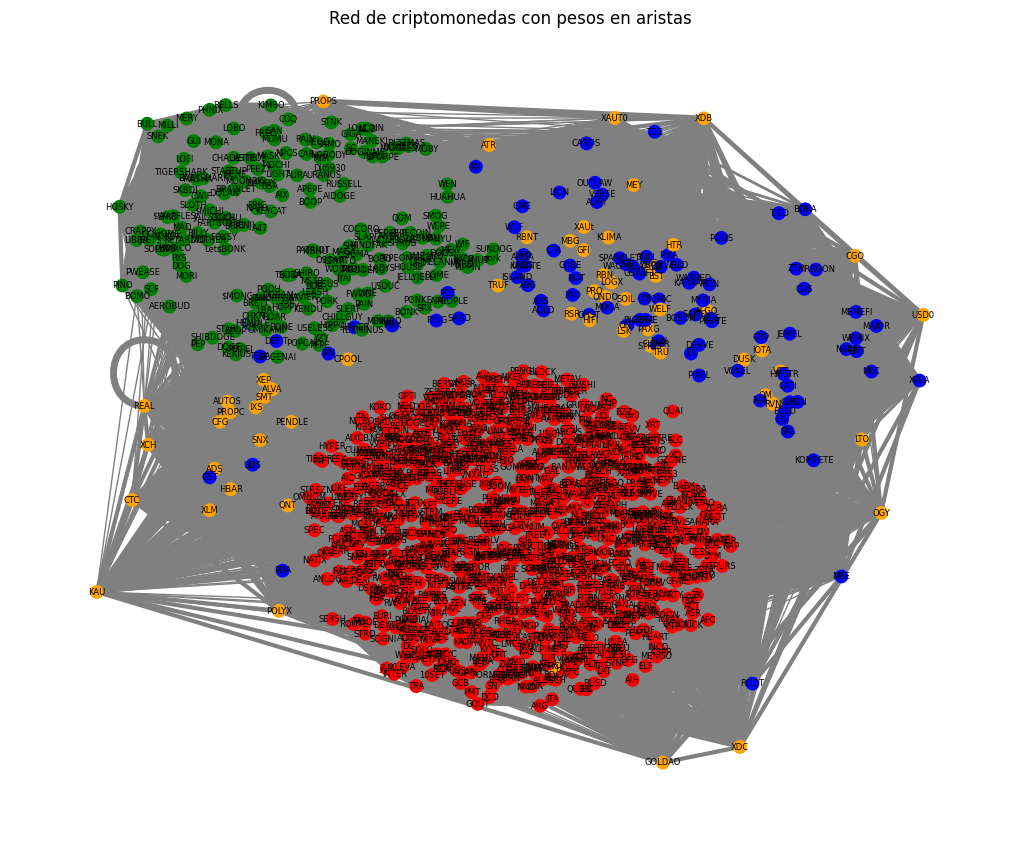

In [16]:
# VISUALIZACIÓN
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.2, iterations=30)
edges = G.edges(data=True)

color_map = {
    "Inteligencia Artificial": "red",
    "Videojuegos": "blue",
    "RWA": "orange",
    "Memes": "green"
}
node_colors = [color_map[G.nodes[n]["category"]] for n in G.nodes()]

edge_widths = [d["weight"] for _, _, d in edges]

nx.draw(
    G, pos,
    with_labels=True,
    node_size=80,
    font_size=6,
    node_color=node_colors,
    edge_color="gray",
    width=edge_widths
)
plt.title("Red de criptomonedas con pesos en aristas", fontsize=12)
plt.show()

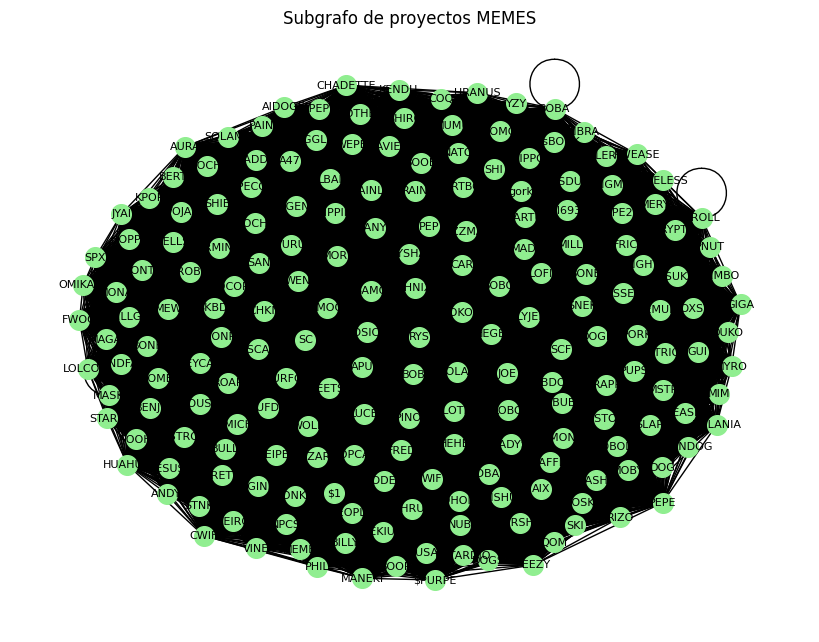

In [17]:
# SUBGRAFO DE MEMES
memes_nodes = [n for n, attr in G.nodes(data=True) if attr["category"] == "Memes"]
subG = G.subgraph(memes_nodes)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, k=0.3)
nx.draw(
    subG, pos,
    with_labels=True,
    node_size=200,
    font_size=8,
    node_color="lightgreen",
    edge_color="black"
)
plt.title("Subgrafo de proyectos MEMES", fontsize=12)
plt.show()

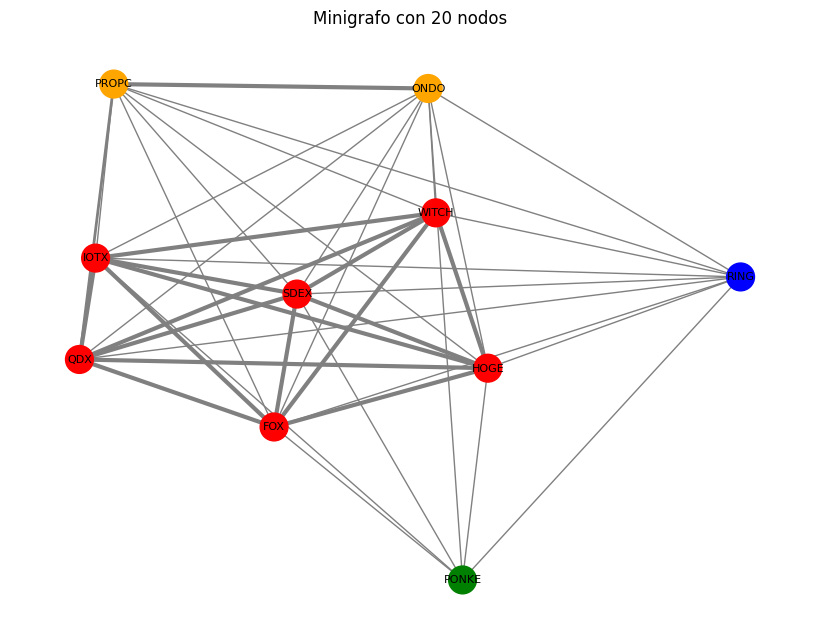

In [31]:
import random

# MINIGRAFO CON 20 NODOS
sample_nodes = random.sample(list(G.nodes()), 10)
miniG = G.subgraph(sample_nodes)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(miniG, k=0.4, iterations=30)

# Colores de nodos según categoría
node_colors = [color_map[miniG.nodes[n]["category"]] for n in miniG.nodes()]

# Grosor de aristas según peso
edge_widths = [d["weight"] for _, _, d in miniG.edges(data=True)]

nx.draw(
    miniG, pos,
    with_labels=True,
    node_size=400,
    font_size=8,
    node_color=node_colors,
    edge_color="gray",
    width=edge_widths
)
plt.title("Minigrafo con 20 nodos", fontsize=12)
plt.show()
